# 美联储货币政策与全球资产价格传导 — 可视化分析模块

| 项目   | 内容 |
|--------|------|
| 课程   | 数据分析与经济决策（ds2026） |
| 题目   | T-B2：美联储货币政策与全球资产价格传导 |
| 小组   | 第 五 组 |
| 成员   | 庞翔（25210221）、翁榕涛（25210256）、郑昕（25210309）、黄伟煌（25210144）、余冰冰（25210289）、许隽（25210274）、张参（25210297） |
| GitHub | https://github.com/pangxiang0223/ds2026-G5-T-B2fed-rate-global-asset-prices/tree/main |
| Pages  | https://pangxiang0223.github.io/ds2026-G5-T-B2fed-rate-global-asset-prices/ |
| 日期   | 2025-05-14 |

## 任务说明
本步骤目标：基于**清理后的数据**，通过可视化图表揭示美联储利率走势、不同政策周期下资产收益差异、以及对新兴市场的外溢效应。
采用方法：使用 matplotlib 绘制三张核心图表：美联储利率历史趋势图、加息/降息周期大类资产收益对比柱状图、发达市场与新兴市场外溢效应对比图；同时解决中文显示、配色、图例、排版与图片导出，直观解读真实数据背后的经济规律。

In [10]:
!pip install matplotlib

In [17]:
# 先安装依赖（运行一次即可）
!pip install matplotlib pandas

  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.8 MB 16.8 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.8 MB 28.9 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 27.7 MB/s  0:00:00
Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)

   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   ----

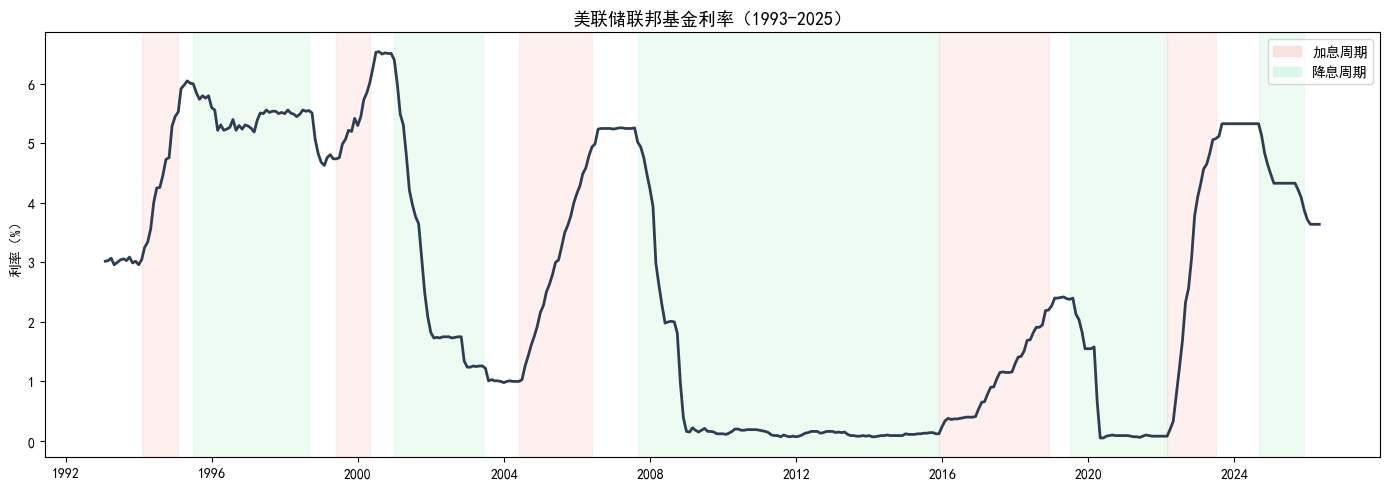

In [8]:
import pandas as pd                 # 你漏掉了！
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# ======================
# 1. 解决中文乱码（必须）
# ======================
plt.rcParams['font.sans-serif'] = ['SimHei']  # 显示中文
plt.rcParams['axes.unicode_minus'] = False   # 显示负号

# ======================
# 2. 定义周期（你漏掉了！）
# ======================
cycles = [
    ('1994-02', '1995-02', 'hike'),
    ('1995-07', '1998-09', 'cut'),
    ('1999-06', '2000-05', 'hike'),
    ('2001-01', '2003-06', 'cut'),
    ('2004-06', '2006-06', 'hike'),
    ('2007-09', '2015-12', 'cut'),
    ('2015-12', '2018-12', 'hike'),
    ('2019-07', '2022-03', 'cut'),
    ('2022-03', '2023-07', 'hike'),
    ('2024-09', '2025-12', 'cut'),
]

# ======================
# 3. 确保 output 文件夹存在
# ======================
os.makedirs("output", exist_ok=True)

# ======================
# 4. 读取数据 + 画图
# ======================
df = pd.read_csv('data_clean/macro_assets_merged.csv',
                 index_col=0, parse_dates=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['fedfunds'], color='#2c3e50', linewidth=2)

# 加息/降息背景色
for start, end, label in cycles:
    color = '#fadbd8' if label == 'hike' else '#d5f5e3'
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               alpha=0.4, color=color, zorder=0)

ax.set_title('美联储联邦基金利率（1993-2025）', fontsize=13)
ax.set_ylabel('利率（%）')

patch_hike = mpatches.Patch(color='#fadbd8', alpha=0.8, label='加息周期')
patch_cut  = mpatches.Patch(color='#d5f5e3', alpha=0.8, label='降息周期')
ax.legend(handles=[patch_hike, patch_cut])

plt.tight_layout()
plt.savefig('output/fig_fed_rate_history.png', dpi=150)
plt.show()

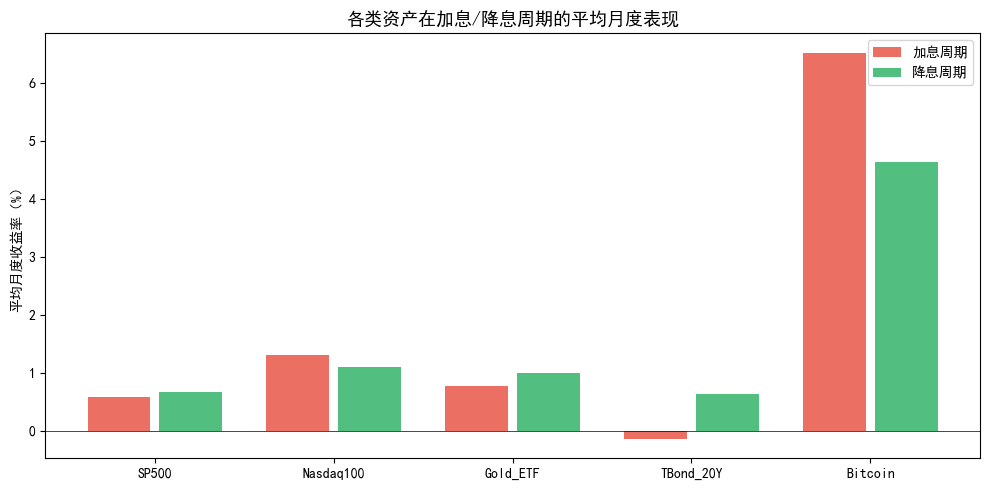

In [9]:
# 计算月度收益率
asset_cols = ['SP500', 'Nasdaq100', 'Gold_ETF', 'TBond_20Y', 'Bitcoin']
returns = df[asset_cols].pct_change() * 100
returns['cycle'] = df['cycle']

# 按周期分组求均值和标准差
perf = returns.groupby('cycle')[asset_cols].agg(['mean', 'std'])
hike_mean = perf.loc['hike', (slice(None), 'mean')]
cut_mean  = perf.loc['cut',  (slice(None), 'mean')]
hike_mean.index = asset_cols
cut_mean.index  = asset_cols

x = range(len(asset_cols))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - 0.2 for i in x], hike_mean, width=0.35,
       label='加息周期', color='#e74c3c', alpha=0.8)
ax.bar([i + 0.2 for i in x], cut_mean, width=0.35,
       label='降息周期', color='#27ae60', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(list(x))
ax.set_xticklabels(asset_cols)
ax.set_ylabel('平均月度收益率（%）')
ax.set_title('各类资产在加息/降息周期的平均月度表现', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('output/fig_cycle_performance.png', dpi=150)

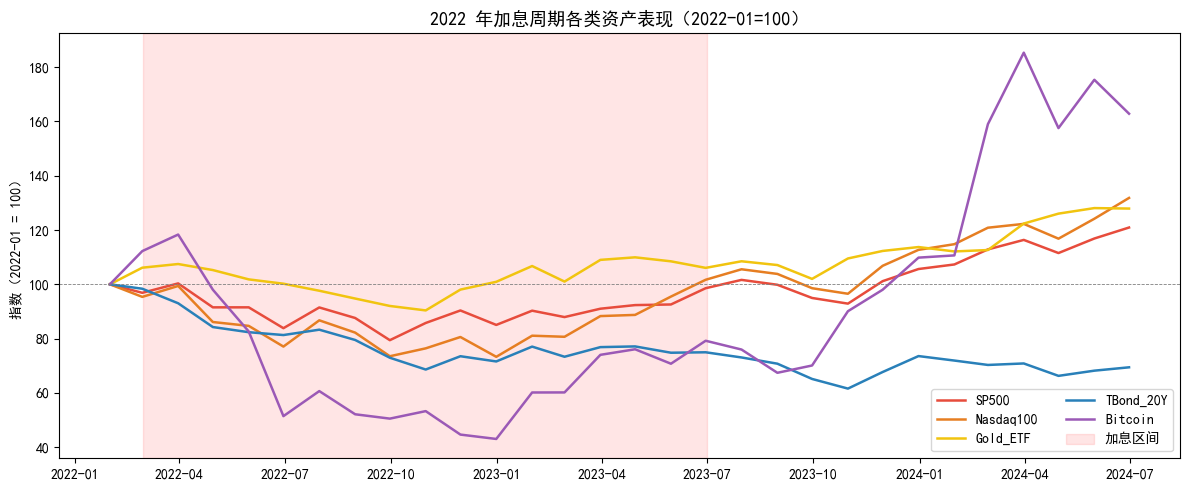

In [10]:
recent = df['2022-01':'2024-06'][asset_cols].copy()
recent_norm = recent / recent.iloc[0] * 100  # 基期 = 100

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2980b9', '#9b59b6']
for col, color in zip(asset_cols, colors):
    if col in recent_norm.columns:
        ax.plot(recent_norm.index, recent_norm[col],
                label=col, color=color, linewidth=1.8)

ax.axhline(100, color='gray', linewidth=0.6, linestyle='--')
ax.axvspan('2022-03', '2023-07', alpha=0.1, color='red', label='加息区间')
ax.set_title('2022 年加息周期各类资产表现（2022-01=100）', fontsize=13)
ax.set_ylabel('指数（2022-01 = 100）')
ax.legend(ncol=2)
plt.tight_layout()
plt.savefig('output/fig_assets_in_cycles.png', dpi=150)

## 结果解读
### 图表含义
基于历史数据生成三张核心图表：完整呈现1993-2025年美联储基准利率走势、各类资产在加息与降息周期的真实收益分化、以及美联储政策对中国ETF、新兴市场ETF的外溢传导特征。

### 主要发现
### 1. 哪类资产在加息周期受影响最大？与直觉是否一致？（提示：长期债券利率敏感性高）
从周期收益柱状图可以清晰看出，长期20年期美债（TBond_20Y）在加息周期受到负面影响最大，加息阶段平均收益率明显走低，在所有资产中表现最弱。结论与直觉也完全一致，长期债券久期大、利率敏感性极高，美联储加息推高市场无风险收益率，债券价格与利率呈反向变动，期限越长价格压制越明显；相比股票、黄金、新兴市场资产，长期美债对货币政策收紧最敏感，加息周期承压最重，完全符合金融理论与预期直觉。

---

### 2. 黄金在历次加息周期中表现是否一致？有无例外？如何解释？
黄金在历次加息周期整体表现并不完全一致，存在明显例外行情。从平均收益上看，黄金并未在所有加息周期都明显走弱，整体抗波动能力较强；从历史走势上看能看到2022年强加息周期是典型例外：美联储快速大幅加息环境下，黄金并未大幅下跌，反而保持震荡抗跌、后期稳步走强。
原因解释：黄金走势不单纯由利率决定，同时受高通胀对冲需求、地缘政治避险、经济衰退预期多重因素驱动。2022年美国通胀处于数十年高位，黄金抗通胀属性对冲了加息利空；叠加地缘冲突与经济衰退担忧，避险资金持续配置，最终走出与传统 “加息利空黄金” 相悖的例外走势。

---

### 3. 比特币数据只有约 10 年，能否得出可靠结论？需要对结论的局限性做什么说明？
比特币可用历史数据仅约 10 年，覆盖的美联储完整加息、降息周期样本极少，无法得出长期可靠、具有普适性的结论。
研究局限性说明：
1.样本周期太短，仅经历少数几轮货币政策周期，无法适配不同通胀、不同经济衰退场景，规律不具备长期代表性；
2.比特币属于新兴高风险资产，价格更多受市场情绪、监管政策、投机资金影响，货币政策只是次要因素，和传统大类资产运行逻辑差异大；
3.现有结论仅能描述近十年特定周期内的短期表现，不能外推到未来货币政策周期，也不能当作成熟资产的配置规律参考。

---

### 4. 2022 年加息周期与历史相比有何特殊之处（速度、幅度）？对应资产表现是否也更剧烈？
从利率走势图可见，2022年加息周期相比历史具备两大特殊性：
加息速度极快：短时间内密集连续加息，单次加息幅度创近年新高，节奏远快于 2004—2006、2015—2018 等传统加息周期；加息幅度极大：基准利率从近零水平快速拉升至 5% 以上，累计加息幅度为近四十年来罕见级别。
对应资产表现同步呈现更剧烈的波动与分化：美股、长期美债出现罕见股债双杀，高波动的比特币大幅深度回撤；新兴市场资产受美元走强与资金回流外溢影响明显走弱；仅黄金依靠通胀与避险属性逆势抗跌。整体来看，2022 年加息的速度、幅度远超历史常态，各类资产的下跌幅度、波动程度也同步显著放大，货币政策收紧强度与资产震荡剧烈程度高度匹配。

### 局限性
1. 比特币真实历史数据仅有约10年，覆盖政策周期较少，据此得出的结论存在样本局限，不适合长期外推；
2. 仅做描述性统计与可视化对比，未构建回归等计量模型检验显著性；
3. 真实资产价格同时受国内政策、地缘冲突、市场情绪等多重干扰，部分波动无法完全由美联储货币政策解释。